In [8]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
!pip install apache-tvm

ERROR: Operation cancelled by user
^C


In [2]:
import tvm
print("TVM version:", tvm.__version__)

TVM version: 0.14.dev273


In [3]:
# Install Package
!pip install torch torchvision onnx onnxruntime pandas matplotlib

In [4]:
# Imports
import time
import json
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt

In [5]:
# Choose model
MODEL_NAME = "resnet18"   # or "mobilenetv2"
BATCH_SIZES = [1, 4, 8]
IMG_SIZE = 224

def get_model(name: str):
    name = name.lower()
    if name == "resnet18":
        return models.resnet18(weights=models.ResNet18_Weights.DEFAULT).eval()
    elif name == "mobilenetv2":
        return models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).eval()
    else:
        raise ValueError("Supported: resnet18, mobilenetv2")

model = get_model(MODEL_NAME)
print(f"Loaded model: {MODEL_NAME}")

Loaded model: resnet18


In [6]:
# Export ONNX
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
onnx_path = f"{MODEL_NAME}.onnx"

torch.onnx.export(
    model,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    opset_version=13,
    do_constant_folding=True,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}
)

print(f"Exported: {onnx_path}")

Exported: resnet18.onnx


In [7]:
#baseline benchmark with ONNX Runtime
def benchmark_onnxruntime(onnx_path, batch, warmup=10, iters=100):
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    input_name = sess.get_inputs()[0].name
    x = np.random.randn(batch, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)

    for _ in range(warmup):
        sess.run(None, {input_name: x})

    start = time.perf_counter()
    for _ in range(iters):
        sess.run(None, {input_name: x})
    end = time.perf_counter()

    total = end - start
    latency_ms = total / iters * 1000
    throughput = batch * iters / total
    return latency_ms, throughput

In [8]:
# run baseline experiments
baseline_rows = []

for batch in BATCH_SIZES:
    latency_ms, throughput = benchmark_onnxruntime(onnx_path, batch=batch)
    baseline_rows.append({
        "model": MODEL_NAME,
        "backend": "onnxruntime_cpu",
        "batch": batch,
        "latency_ms": latency_ms,
        "throughput_img_s": throughput
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

,model,backend,batch,latency_ms,throughput_img_s
0,resnet18,onnxruntime_cpu,1,59.514110,16.802738
1,resnet18,onnxruntime_cpu,4,260.781579,15.338507
2,resnet18,onnxruntime_cpu,8,526.836329,15.184982


In [ ]:
# save baseline results
baseline_df.to_csv("baseline_results.csv", index=False)
baseline_df.to_json("baseline_results.json", orient="records", indent=2)

print("Saved baseline_results.csv and baseline_results.json")

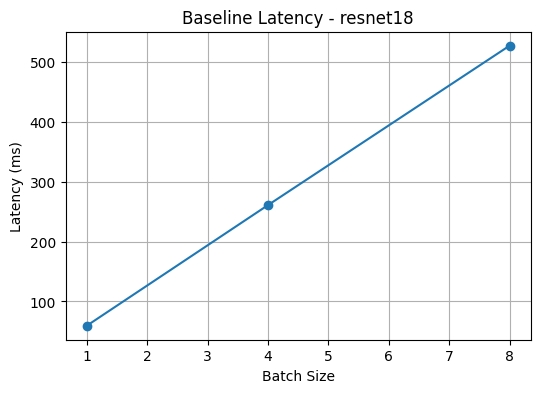

In [9]:
# baseline chart
plt.figure(figsize=(6,4))
plt.plot(baseline_df["batch"], baseline_df["latency_ms"], marker="o")
plt.title(f"Baseline Latency - {MODEL_NAME}")
plt.xlabel("Batch Size")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.show()

In [10]:
#download File to run in VS code
from google.colab import files

files.download(onnx_path)
files.download("baseline_results.csv")
files.download("baseline_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
#TVM_Compile
import os
import onnx
import tvm
from tvm import relay

def compile_onnx_to_tvm(onnx_file, batch_size, target="llvm", out_dir="tvm_artifacts"):
    os.makedirs(out_dir, exist_ok=True)

    print(f"Loading ONNX model: {onnx_file} for batch {batch_size}")
    onnx_model = onnx.load(onnx_file)
    shape_dict = {"input": (batch_size, 3, 224, 224)}
    mod, params = relay.frontend.from_onnx(onnx_model, shape_dict, freeze_params=True)

    print(f"Compiling for target: {target}...")
    with tvm.transform.PassContext(opt_level=3):
        lib = relay.build(mod, target=target, params=params)

    lib.export_library(os.path.join(out_dir, "model.so"))
    with open(os.path.join(out_dir, "graph.json"), "w") as f:
        f.write(lib.get_graph_json())
    with open(os.path.join(out_dir, "params.bin"), "wb") as f:
        f.write(relay.save_param_dict(lib.get_params()))

    print(f"TVM artifacts saved to {out_dir}")

# Run the compilation using variables from previous cells
compile_onnx_to_tvm(onnx_path, BATCH_SIZES[0])

Loading ONNX model: resnet18.onnx for batch 1
Compiling for target: llvm...


TVM artifacts saved to tvm_artifacts


In [12]:
#Benchmark fix to artifacts generated successfully
import tvm
from tvm import relay
import torch
import torchvision.models as models
import numpy as np
import os

# -----------------------------
# CONFIG
# -----------------------------
#MODEL_NAME = "resnet18"
#BATCH_SIZES = [1, 8, 16]
ARTIFACT_ROOT = "artifacts"

os.makedirs(ARTIFACT_ROOT, exist_ok=True)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

# -----------------------------
# LOOP OVER BATCHES
# -----------------------------
for batch in BATCH_SIZES:

    print(f"\nCompiling for batch {batch}...")

    input_shape = (batch, 3, 224, 224)
    dummy_input = torch.randn(input_shape)

    scripted_model = torch.jit.trace(model, dummy_input)

    mod, params = relay.frontend.from_pytorch(
        scripted_model,
        [("input", input_shape)]
    )

    with tvm.transform.PassContext(opt_level=3):
        lib = relay.build(mod, target="llvm", params=params)

    # -----------------------------
    # SAVE ARTIFACTS
    # -----------------------------
    artifact_dir = os.path.join(ARTIFACT_ROOT, f"batch_{batch}")
    os.makedirs(artifact_dir, exist_ok=True)

    # Save library
    lib.export_library(os.path.join(artifact_dir, "model.so"))

    # Save graph
    with open(os.path.join(artifact_dir, "graph.json"), "w") as f:
        f.write(lib.get_graph_json())

    # Save params
    with open(os.path.join(artifact_dir, "params.bin"), "wb") as f:
        f.write(relay.save_param_dict(lib.get_params()))

print("\n✅ All artifacts generated successfully!")


Compiling for batch 1...

Compiling for batch 4...

Compiling for batch 8...

✅ All artifacts generated successfully!


In [13]:
# tvm_benchmark
import argparse
import json
import os
import numpy as np
import pandas as pd
import tvm
from tvm import relay
from tvm.contrib import graph_executor

def load_params(path):
    with open(path, "rb") as f:
        return relay.load_param_dict(f.read())

def benchmark_tvm(artifact_dir, batch, device_name="cpu", repeat=100):
    lib = tvm.runtime.load_module(os.path.join(artifact_dir, "model.so"))

    with open(os.path.join(artifact_dir, "graph.json")) as f:
        graph_json = f.read()

    params = load_params(os.path.join(artifact_dir, "params.bin"))

    dev = tvm.cpu(0) if device_name == "cpu" else tvm.cuda(0)
    module = graph_executor.create(graph_json, lib, dev)
    module.load_params(relay.save_param_dict(params))

    x = np.random.randn(batch, 3, 224, 224).astype("float32")
    module.set_input("input", x)

    # warmup
    for _ in range(10):
        module.run()

    ftimer = module.module.time_evaluator("run", dev, number=repeat)
    prof = ftimer()
    latency_ms = prof.mean * 1000
    throughput = batch / prof.mean

    return latency_ms, throughput

def main(model_name, artifact_root, batches, device):
    rows = []

    for batch in batches:
        artifact_dir = os.path.join(artifact_root, f"batch_{batch}")
        latency_ms, throughput = benchmark_tvm(artifact_dir, batch=batch, device_name=device)
        rows.append({
            "model": model_name,
            "backend": f"tvm_{device}",
            "batch": batch,
            "latency_ms": latency_ms,
            "throughput_img_s": throughput
        })

    df = pd.DataFrame(rows)
    df.to_csv("tvm_results.csv", index=False)
    df.to_json("tvm_results.json", orient="records", indent=2)

    print(df)

if __name__ == "__main__":
    # Assuming MODEL_NAME and BATCH_SIZES are defined elsewhere in the notebook
    # For device, we'll default to 'cpu' or retrieve from a global if available.
    # For artifact_root, we'll use a default.
    main(MODEL_NAME, artifact_root="artifacts", batches=BATCH_SIZES, device="cpu")

      model  backend  batch   latency_ms  throughput_img_s
0  resnet18  tvm_cpu      1   289.307240          3.456533
1  resnet18  tvm_cpu      4  1757.670767          2.275739
2  resnet18  tvm_cpu      8  3457.544690          2.313781


In [14]:
#merge_results
import pandas as pd

baseline = pd.read_csv("baseline_results.csv")
tvm = pd.read_csv("tvm_results.csv")

merged = baseline.merge(
    tvm,
    on=["model", "batch"],
    suffixes=("_baseline", "_tvm")
)

merged["speedup"] = merged["latency_ms_baseline"] / merged["latency_ms_tvm"]
merged.to_csv("final_results.csv", index=False)
merged.to_json("final_results.json", orient="records", indent=2)

print(merged)

      model backend_baseline  batch  latency_ms_baseline  \
0  resnet18  onnxruntime_cpu      1            69.459407   
1  resnet18  onnxruntime_cpu      4           260.003896   
2  resnet18  onnxruntime_cpu      8           563.535473   

   throughput_img_s_baseline backend_tvm  latency_ms_tvm  \
0                  14.396898     tvm_cpu      289.307240   
1                  15.384385     tvm_cpu     1757.670767   
2                  14.196089     tvm_cpu     3457.544690   

   throughput_img_s_tvm   speedup  
0              3.456533  0.240089  
1              2.275739  0.147925  
2              2.313781  0.162987  


#Debugging Code-stuff, version models

In [ ]:
# Uninstall potentially conflicting packages to ensure a clean slate
!pip uninstall -y apache-tvm onnx numpy

# Install numpy and onnx versions known to be compatible with TVM 0.14.dev
!pip install numpy==1.26.4
!pip install onnx==1.12.0

# Reinstall apache-tvm. Pip should now resolve dependencies with the pinned numpy and onnx
!pip install apache-tvm

# Verify installations
import onnx
import tvm
print(f"ONNX version: {onnx.__version__}")
print(f"TVM version: {tvm.__version__}")

In [ ]:
!pip install numpy==1.26.4
!pip install onnx==1.13.0
!pip install apache-tvm

import onnx
import tvm
print(f"ONNX version: {onnx.__version__}")
print(f"TVM version: {tvm.__version__}")